# Predicting Airline Satisfaction
## Score: .95859

## Load Data

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("playground-series-s6e10/train.csv")
test = pd.read_csv("playground-series-s6e10/test.csv")
sample_submission = pd.read_csv("playground-series-s6e10/sample_submission.csv")

## EDA

In [28]:
display(train.shape, test.shape)
display(train.head())
display(train.dtypes)
display(train.describe(include="all").T)
display(train.isna().sum())
display(test.isna().sum())
display(train["satisfaction"].value_counts(normalize=True))

cat_cols = train.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "satisfaction"]
for col in cat_cols:
    display(col, train[col].value_counts())

(699635, 23)

(299844, 22)

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


id                                     int64
Age                                    int64
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Gender                                   str
Customer Type                            str
Type of Travel                           str
Class                                    str
satisfacti

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,699635.0,NaN,NaN,NaN,349817.0,201967.37213,0.0,174908.5,349817.0,524725.5,699634.0
Age,699635.0,NaN,NaN,NaN,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,NaN,NaN,NaN,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Inflight wifi service,699635.0,NaN,NaN,NaN,2.778722,1.280419,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,699635.0,NaN,NaN,NaN,3.15621,1.47539,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,699635.0,NaN,NaN,NaN,2.81324,1.32955,0.0,2.0,3.0,4.0,5.0
Gate location,699635.0,NaN,NaN,NaN,3.013734,1.254014,0.0,2.0,3.0,4.0,5.0
Food and drink,699635.0,NaN,NaN,NaN,3.265644,1.300202,0.0,2.0,3.0,4.0,5.0
Online boarding,699635.0,NaN,NaN,NaN,3.364156,1.288538,0.0,2.0,4.0,4.0,5.0
Seat comfort,699635.0,NaN,NaN,NaN,3.56895,1.275333,0.0,3.0,4.0,5.0,5.0


...

Customer Type
Loyal Customer       576990
disloyal Customer    122645
Name: count, dtype: int64

'Type of Travel'

Type of Travel
Business travel    497441
Personal Travel    202194
Name: count, dtype: int64

'Class'

Class
Business    342212
Eco         327404
Eco Plus     30019
Name: count, dtype: int64

## Feature Distributions

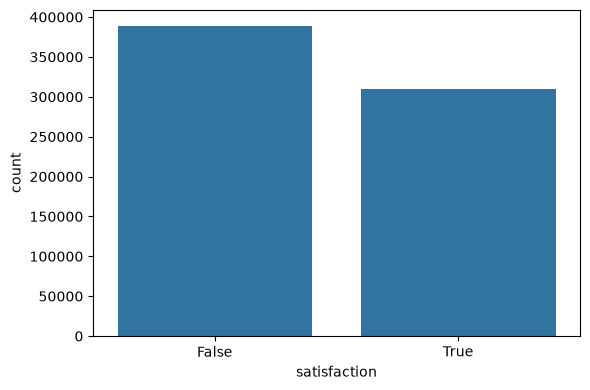

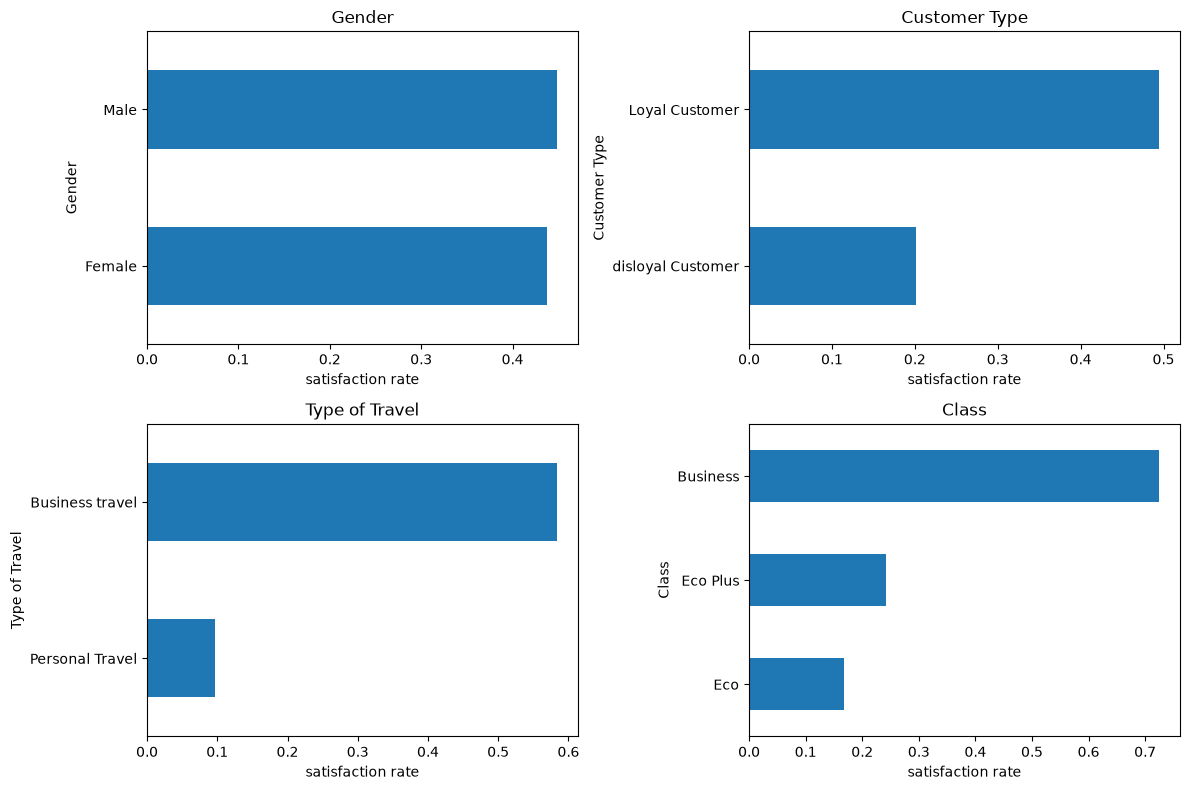

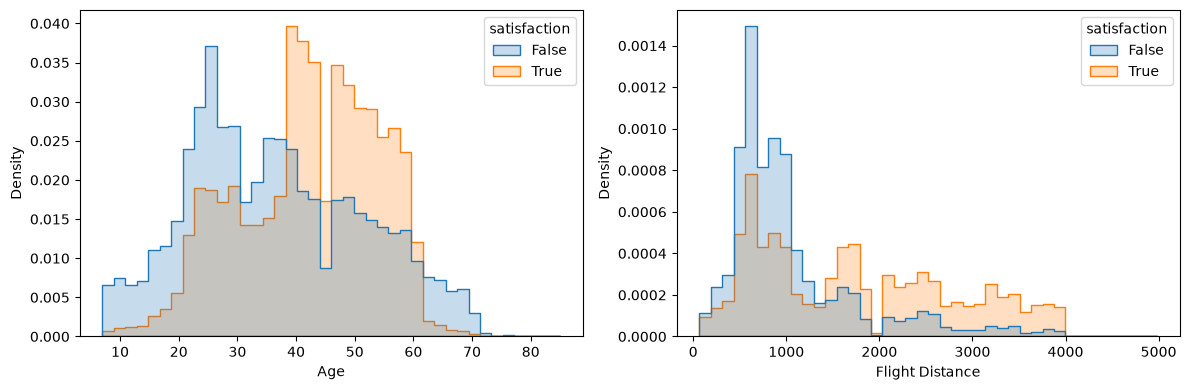

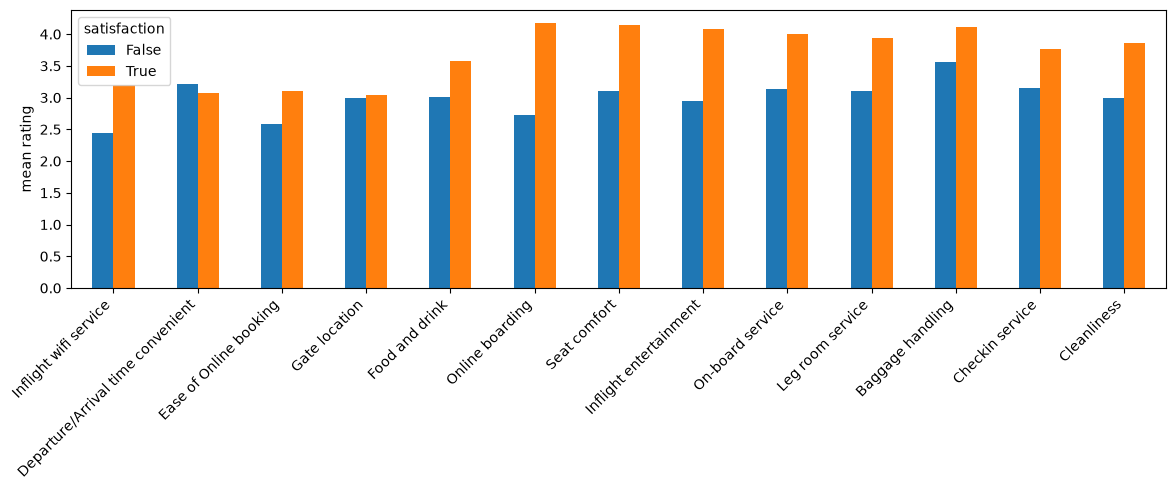

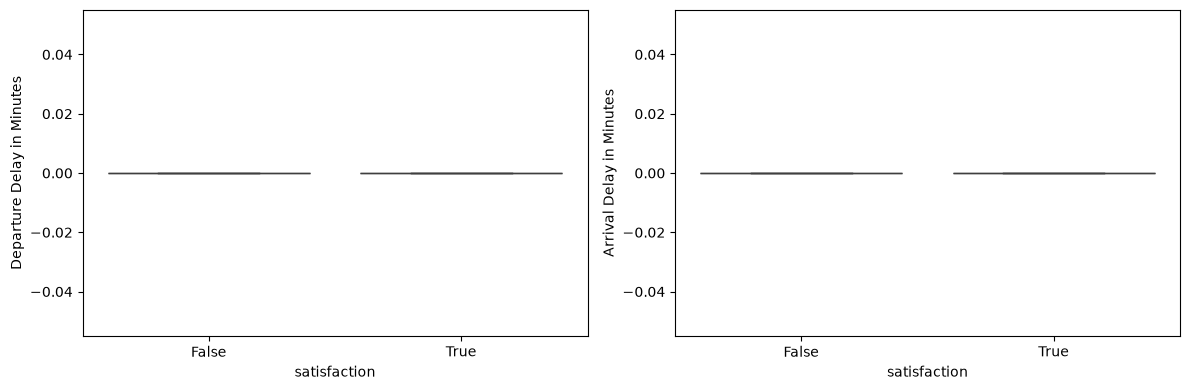

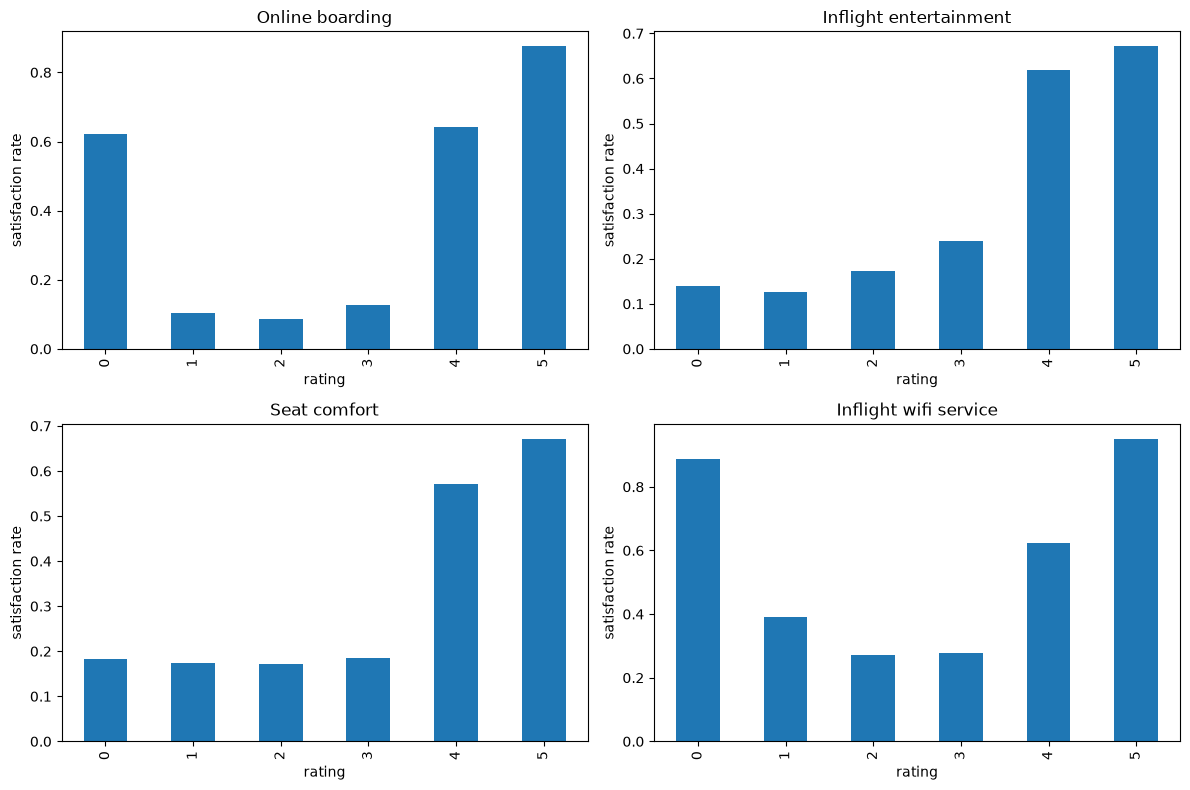

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train, x="satisfaction", ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = train.groupby(col, observed=True)["satisfaction"].mean().sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("satisfaction rate")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Age", "Flight Distance"]):
    sns.histplot(data=train, x=col, hue="satisfaction", bins=40, element="step", common_norm=False, stat="density", ax=ax)
plt.tight_layout()
plt.show()

rating_cols = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
]

rating_means = train.groupby("satisfaction", observed=True)[rating_cols].mean().T
rating_means.plot(kind="bar", figsize=(12, 5))
plt.ylabel("mean rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Departure Delay in Minutes", "Arrival Delay in Minutes"]):
    sns.boxplot(data=train, x="satisfaction", y=col, ax=ax, showfliers=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["Online boarding", "Inflight entertainment", "Seat comfort", "Inflight wifi service"]):
    rate = train.groupby(col, observed=True)["satisfaction"].mean()
    rate.plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("satisfaction rate")
    ax.set_xlabel("rating")
plt.tight_layout()
plt.show()

## Correlation Matrix

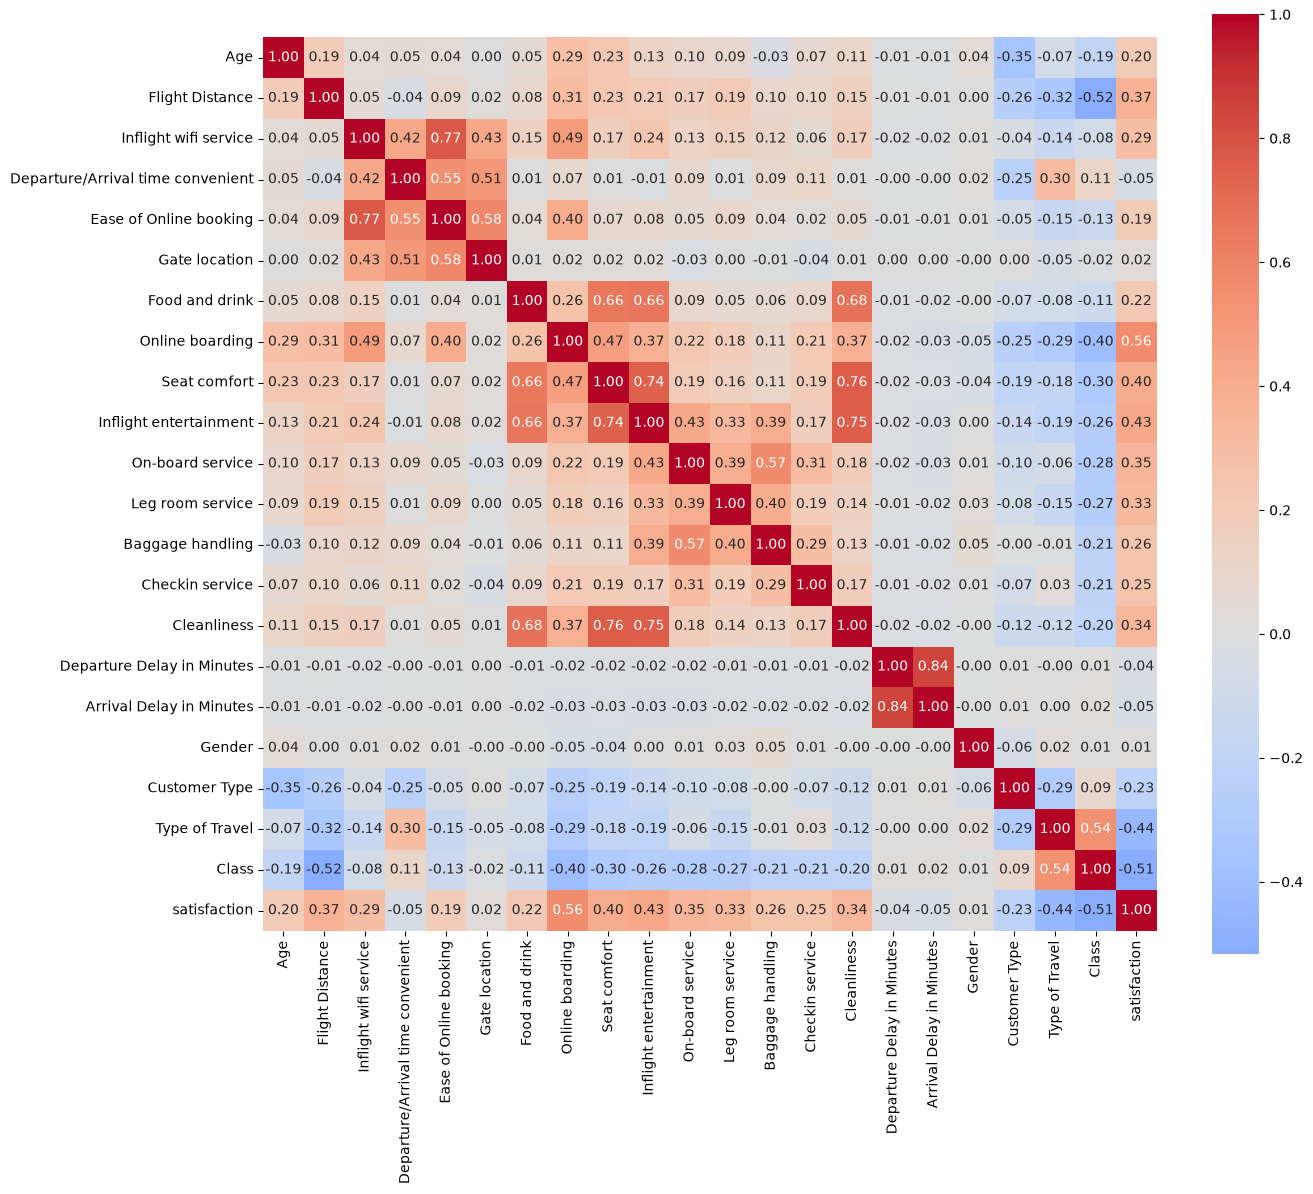

satisfaction                         1.000000
Online boarding                      0.559583
Inflight entertainment               0.430755
Seat comfort                         0.401488
Flight Distance                      0.370038
On-board service                     0.346618
Cleanliness                          0.338853
Leg room service                     0.330116
Inflight wifi service                0.291275
Baggage handling                     0.258118
Checkin service                      0.249799
Food and drink                       0.218058
Age                                  0.202708
Ease of Online booking               0.190878
Gate location                        0.022834
Gender                               0.011169
Departure Delay in Minutes          -0.035815
Departure/Arrival time convenient   -0.049185
Arrival Delay in Minutes            -0.051641
Customer Type                       -0.225161
Type of Travel                      -0.444418
Class                             

In [30]:
corr_df = train.drop(columns=["id"]).copy()
corr_df["satisfaction"] = corr_df["satisfaction"].astype(int)
for col in cat_cols:
    corr_df[col] = corr_df[col].astype("category").cat.codes

corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.tight_layout()
plt.show()

display(corr["satisfaction"].sort_values(ascending=False))

## Preprocessing

In [31]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

TARGET = "satisfaction"
ID_COL = "id"
CAT_COLS = ["Gender", "Customer Type", "Type of Travel", "Class"]
RATING_COLS = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
]
INTER_COLS = ["travel_class", "cust_travel", "cust_class"]
FEATURE_COLS = [c for c in train.columns if c not in [ID_COL, TARGET]]


def prepare_features(df, inter=False, ratings_as_cat=False):
    out = df[FEATURE_COLS].copy()
    out["Arrival Delay in Minutes"] = out["Arrival Delay in Minutes"].fillna(
        out["Departure Delay in Minutes"]
    )
    cat_cols = list(CAT_COLS)
    if inter:
        out["travel_class"] = (
            out["Type of Travel"].astype(str) + "|" + out["Class"].astype(str)
        ).astype("category")
        out["cust_travel"] = (
            out["Customer Type"].astype(str) + "|" + out["Type of Travel"].astype(str)
        ).astype("category")
        out["cust_class"] = (
            out["Customer Type"].astype(str) + "|" + out["Class"].astype(str)
        ).astype("category")
        cat_cols = cat_cols + INTER_COLS
    if ratings_as_cat:
        cat_cols = cat_cols + RATING_COLS
    for col in cat_cols:
        out[col] = out[col].astype("category")
    return out, cat_cols


y = train[TARGET].astype(int)
X, _ = prepare_features(train, inter=False, ratings_as_cat=False)
X_test, _ = prepare_features(test, inter=False, ratings_as_cat=False)
X_cat, _ = prepare_features(train, inter=False, ratings_as_cat=True)
X_test_cat, _ = prepare_features(test, inter=False, ratings_as_cat=True)
X_inter, cat_cols_inter = prepare_features(train, inter=True, ratings_as_cat=False)
X_test_inter, _ = prepare_features(test, inter=True, ratings_as_cat=False)

display(X.shape, X_cat.shape, X_inter.shape, X_test.shape)
display(y.value_counts(normalize=True))
display(X.isna().sum().sum(), X_test.isna().sum().sum())


(699635, 21)

(699635, 21)

(699635, 24)

(299844, 21)

satisfaction
0    0.556427
1    0.443573
Name: proportion, dtype: float64

np.int64(0)

np.int64(0)

## Model

In [32]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
folds = list(skf.split(X, y))

xgb_params_a = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 7,
    "learning_rate": 0.04,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 5,
    "reg_lambda": 1.5,
    "max_cat_to_onehot": 4,
}
xgb_params_b = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 8,
    "learning_rate": 0.03,
    "subsample": 0.9,
    "colsample_bytree": 0.75,
    "min_child_weight": 3,
    "reg_lambda": 1.5,
    "reg_alpha": 0.1,
    "max_cat_to_onehot": 4,
}
lgb_param_list = [
    {
        "name": "lgb_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.05,
            "num_leaves": 64,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 40,
            "verbosity": -1,
            "seed": 42,
        },
    },
    {
        "name": "lgb2_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.035,
            "num_leaves": 96,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 25,
            "verbosity": -1,
            "seed": 7,
            "bagging_seed": 7,
            "feature_fraction_seed": 7,
        },
    },
    {
        "name": "lgb3_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.03,
            "num_leaves": 48,
            "feature_fraction": 0.7,
            "bagging_fraction": 0.7,
            "bagging_freq": 1,
            "min_child_samples": 60,
            "verbosity": -1,
            "seed": 99,
            "bagging_seed": 99,
            "feature_fraction_seed": 99,
        },
    },
]

model_names = ["xgb_a", "xgb_b", "xgb_int"] + [cfg["name"] for cfg in lgb_param_list] + ["cb_int"]
oof = {name: np.zeros(len(X)) for name in model_names}
test_oof = {name: np.zeros(len(X_test)) for name in model_names}
fold_scores = {name: [] for name in model_names}
xgb_models_a, xgb_models_b, xgb_models_int = [], [], []
lgb_models = {cfg["name"]: [] for cfg in lgb_param_list}
cb_models = []

for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    dtrain = xgb.DMatrix(X.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid = xgb.DMatrix(X.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    model_a = xgb.train(
        params=xgb_params_a,
        dtrain=dtrain,
        num_boost_round=3500,
        evals=[(dvalid, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_a = model_a.predict(dvalid)
    oof["xgb_a"][va_idx] = pred_a
    test_oof["xgb_a"] += model_a.predict(dtest) / n_splits
    fold_scores["xgb_a"].append(roc_auc_score(y_va, pred_a))
    xgb_models_a.append(model_a)

    dtrain_b = xgb.DMatrix(X_cat.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid_b = xgb.DMatrix(X_cat.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_b = xgb.DMatrix(X_test_cat, enable_categorical=True)
    model_b = xgb.train(
        params=xgb_params_b,
        dtrain=dtrain_b,
        num_boost_round=3500,
        evals=[(dvalid_b, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_b = model_b.predict(dvalid_b)
    oof["xgb_b"][va_idx] = pred_b
    test_oof["xgb_b"] += model_b.predict(dtest_b) / n_splits
    fold_scores["xgb_b"].append(roc_auc_score(y_va, pred_b))
    xgb_models_b.append(model_b)

    dtrain_i = xgb.DMatrix(X_inter.iloc[tr_idx], label=y_tr, enable_categorical=True)
    dvalid_i = xgb.DMatrix(X_inter.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_i = xgb.DMatrix(X_test_inter, enable_categorical=True)
    model_i = xgb.train(
        params=xgb_params_a,
        dtrain=dtrain_i,
        num_boost_round=3500,
        evals=[(dvalid_i, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_i = model_i.predict(dvalid_i)
    oof["xgb_int"][va_idx] = pred_i
    test_oof["xgb_int"] += model_i.predict(dtest_i) / n_splits
    fold_scores["xgb_int"].append(roc_auc_score(y_va, pred_i))
    xgb_models_int.append(model_i)

    for cfg in lgb_param_list:
        name = cfg["name"]
        dtrain_lgb = lgb.Dataset(
            X_inter.iloc[tr_idx],
            label=y_tr,
            categorical_feature=cat_cols_inter,
            free_raw_data=False,
        )
        dvalid_lgb = lgb.Dataset(
            X_inter.iloc[va_idx],
            label=y_va,
            categorical_feature=cat_cols_inter,
            free_raw_data=False,
        )
        model_lgb = lgb.train(
            params=cfg["params"],
            train_set=dtrain_lgb,
            num_boost_round=4500,
            valid_sets=[dvalid_lgb],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
        )
        pred_lgb = model_lgb.predict(X_inter.iloc[va_idx])
        oof[name][va_idx] = pred_lgb
        test_oof[name] += model_lgb.predict(X_test_inter) / n_splits
        fold_scores[name].append(roc_auc_score(y_va, pred_lgb))
        lgb_models[name].append(model_lgb)

    X_tr_cb = X_inter.iloc[tr_idx].copy()
    X_va_cb = X_inter.iloc[va_idx].copy()
    X_test_cb = X_test_inter.copy()
    for col in cat_cols_inter:
        X_tr_cb[col] = X_tr_cb[col].astype(str)
        X_va_cb[col] = X_va_cb[col].astype(str)
        X_test_cb[col] = X_test_cb[col].astype(str)
    model_cb = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        task_type="GPU",
        devices="0",
        iterations=4000,
        learning_rate=0.04,
        depth=8,
        l2_leaf_reg=4,
        random_seed=42,
        od_type="Iter",
        od_wait=120,
        verbose=False,
        bootstrap_type="Bayesian",
    )
    model_cb.fit(
        X_tr_cb,
        y_tr,
        eval_set=(X_va_cb, y_va),
        cat_features=cat_cols_inter,
        use_best_model=True,
    )
    pred_cb = model_cb.predict_proba(X_va_cb)[:, 1]
    oof["cb_int"][va_idx] = pred_cb
    test_oof["cb_int"] += model_cb.predict_proba(X_test_cb)[:, 1] / n_splits
    fold_scores["cb_int"].append(roc_auc_score(y_va, pred_cb))
    cb_models.append(model_cb)

    print(
        f"fold {fold}: "
        + ", ".join(f"{name}={fold_scores[name][-1]:.6f}" for name in model_names)
    )

for name in model_names:
    print(
        f"{name}: oof={roc_auc_score(y, oof[name]):.6f} "
        f"mean={np.mean(fold_scores[name]):.6f} +/- {np.std(fold_scores[name]):.6f}"
    )

O = np.column_stack([oof[name] for name in model_names])
T = np.column_stack([test_oof[name] for name in model_names])


def blend_auc(weights):
    w = np.abs(weights)
    w = w / w.sum()
    return -roc_auc_score(y, O @ w)


opt = minimize(blend_auc, x0=np.ones(len(model_names)) / len(model_names), method="Nelder-Mead")
blend_weights = np.abs(opt.x)
blend_weights = blend_weights / blend_weights.sum()
oof_pred = O @ blend_weights
test_pred = T @ blend_weights
oof_auc = roc_auc_score(y, oof_pred)

print("blend weights:", dict(zip(model_names, np.round(blend_weights, 4))))
print(f"blend oof auc: {oof_auc:.6f}")
print(f"equal-weight oof auc: {roc_auc_score(y, O.mean(axis=1)):.6f}")


Default metric period is 5 because AUC is/are not implemented for GPU


fold 1: xgb_a=0.958827, xgb_b=0.958794, xgb_int=0.958944, lgb_int=0.958946, lgb2_int=0.959049, lgb3_int=0.959099, cb_int=0.958651


Default metric period is 5 because AUC is/are not implemented for GPU


fold 2: xgb_a=0.957637, xgb_b=0.957625, xgb_int=0.957859, lgb_int=0.957811, lgb2_int=0.957897, lgb3_int=0.957923, cb_int=0.957541


Default metric period is 5 because AUC is/are not implemented for GPU


fold 3: xgb_a=0.959596, xgb_b=0.959692, xgb_int=0.959578, lgb_int=0.959491, lgb2_int=0.959652, lgb3_int=0.959742, cb_int=0.959316


Default metric period is 5 because AUC is/are not implemented for GPU


fold 4: xgb_a=0.958726, xgb_b=0.958712, xgb_int=0.958999, lgb_int=0.958974, lgb2_int=0.959079, lgb3_int=0.959030, cb_int=0.958533


Default metric period is 5 because AUC is/are not implemented for GPU


fold 5: xgb_a=0.958898, xgb_b=0.958961, xgb_int=0.958990, lgb_int=0.959214, lgb2_int=0.959302, lgb3_int=0.959312, cb_int=0.958935
xgb_a: oof=0.958730 mean=0.958737 +/- 0.000630
xgb_b: oof=0.958754 mean=0.958757 +/- 0.000663
xgb_int: oof=0.958866 mean=0.958874 +/- 0.000559
lgb_int: oof=0.958879 mean=0.958887 +/- 0.000573
lgb2_int: oof=0.958987 mean=0.958996 +/- 0.000590
lgb3_int: oof=0.959012 mean=0.959021 +/- 0.000603
cb_int: oof=0.958587 mean=0.958595 +/- 0.000592
blend weights: {'xgb_a': np.float64(0.0), 'xgb_b': np.float64(0.1401), 'xgb_int': np.float64(0.1853), 'lgb_int': np.float64(0.0944), 'lgb2_int': np.float64(0.3168), 'lgb3_int': np.float64(0.21), 'cb_int': np.float64(0.0535)}
blend oof auc: 0.959219
equal-weight oof auc: 0.959186


## Inference

In [33]:
test_pred = T @ blend_weights
oof_pred = O @ blend_weights

pred_summary = pd.DataFrame(
    {
        "oof": pd.Series(oof_pred).describe(),
        "test": pd.Series(test_pred).describe(),
    }
)
display(pred_summary)
display(
    pd.DataFrame(
        {
            "model": model_names,
            "weight": blend_weights,
            "oof_auc": [roc_auc_score(y, oof[n]) for n in model_names],
        }
    )
)


,oof,test
count,699635.000000,299844.000000
mean,0.443533,0.443682
std,0.430205,0.430148
min,0.003649,0.003471
25%,0.036381,0.036415
50%,0.185871,0.186460
75%,0.947713,0.947844
max,0.991781,0.988323


,model,weight,oof_auc
0,xgb_a,0.000006,0.958730
1,xgb_b,0.140108,0.958754
2,xgb_int,0.185320,0.958866
3,lgb_int,0.094353,0.958879
4,lgb2_int,0.316758,0.958987
5,lgb3_int,0.209955,0.959012
6,cb_int,0.053500,0.958587


## Make Submission File

In [34]:
submission = sample_submission.copy()
submission["satisfaction"] = test_pred
submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
display(submission.head())
display(submission.shape)
print(submission_path)

,id,satisfaction
0,699635,0.239947
1,699636,0.867855
2,699637,0.910486
3,699638,0.070328
4,699639,0.052570


(299844, 2)

submission.csv


## Model Validation

,xgb_a,xgb_b,xgb_int,lgb_int,lgb2_int,lgb3_int,cb_int
fold_1,0.958827,0.958794,0.958944,0.958946,0.959049,0.959099,0.958651
fold_2,0.957637,0.957625,0.957859,0.957811,0.957897,0.957923,0.957541
fold_3,0.959596,0.959692,0.959578,0.959491,0.959652,0.959742,0.959316
fold_4,0.958726,0.958712,0.958999,0.958974,0.959079,0.959030,0.958533
fold_5,0.958898,0.958961,0.958990,0.959214,0.959302,0.959312,0.958935


,xgb_a,xgb_b,xgb_int,lgb_int,lgb2_int,lgb3_int,cb_int
mean,0.958737,0.958757,0.958874,0.958887,0.958996,0.959021,0.958595
std,0.000704,0.000742,0.000624,0.000640,0.000660,0.000674,0.000662


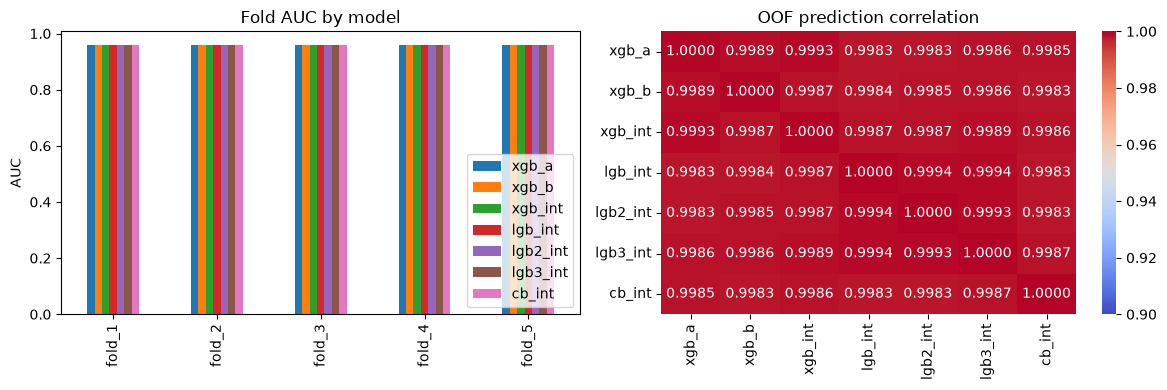

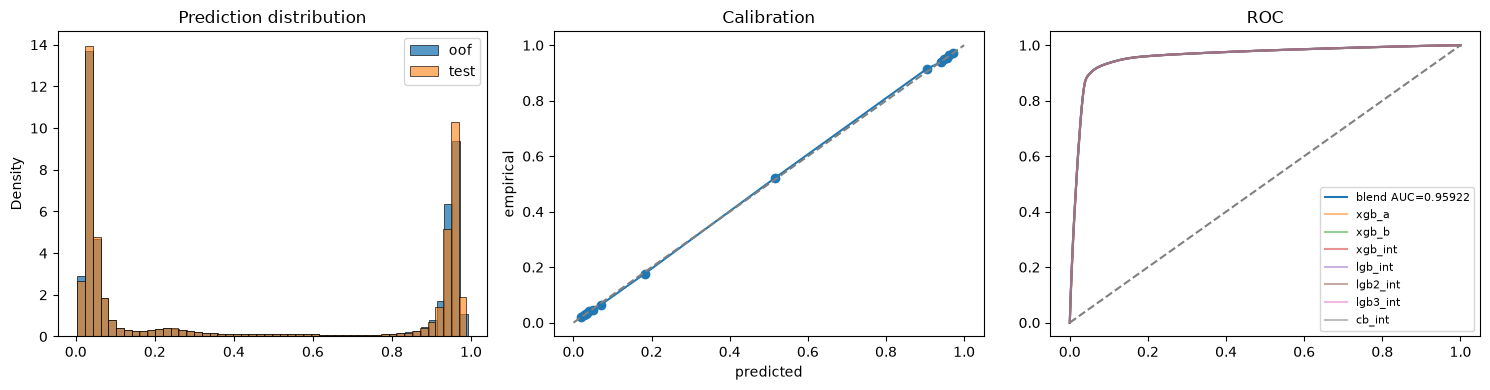

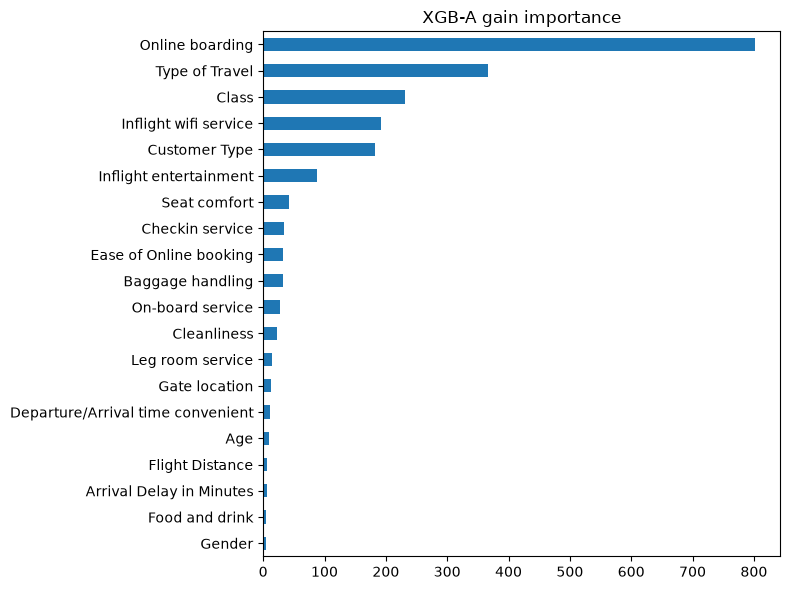

Online boarding                      802.424683
Type of Travel                       367.028137
Class                                230.986938
Inflight wifi service                192.768707
Customer Type                        182.967651
Inflight entertainment                87.663979
Seat comfort                          42.312096
Checkin service                       34.742924
Ease of Online booking                33.078724
Baggage handling                      31.538803
On-board service                      27.779055
Cleanliness                           22.773367
Leg room service                      15.021598
Gate location                         13.575852
Departure/Arrival time convenient     10.621278
Age                                    8.752895
Flight Distance                        6.119944
Arrival Delay in Minutes               5.595627
Food and drink                         5.373770
Gender                                 3.963517
dtype: float64

,id,y,oof,abs_error
211257,211257,1,0.005674,0.994326
447771,447771,1,0.007227,0.992773
675194,675194,1,0.008008,0.991992
218804,218804,1,0.008050,0.991950
171002,171002,1,0.008140,0.991860
507755,507755,1,0.008815,0.991185
409576,409576,1,0.009141,0.990859
245703,245703,1,0.009313,0.990687
193674,193674,1,0.009481,0.990519
10144,10144,1,0.009623,0.990377


blend oof auc: 0.959219


In [35]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

fold_auc_df = pd.DataFrame(fold_scores)
fold_auc_df.index = [f"fold_{i}" for i in range(1, n_splits + 1)]
display(fold_auc_df)
display(fold_auc_df.agg(["mean", "std"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fold_auc_df.plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("AUC")
axes[0].set_title("Fold AUC by model")
axes[0].legend(loc="lower right")

corr_preds = pd.DataFrame({name: oof[name] for name in model_names}).corr()
sns.heatmap(corr_preds, annot=True, fmt=".4f", cmap="coolwarm", ax=axes[1], vmin=0.9, vmax=1.0)
axes[1].set_title("OOF prediction correlation")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(oof_pred, bins=50, stat="density", ax=axes[0], color="C0", label="oof")
sns.histplot(test_pred, bins=50, stat="density", ax=axes[0], color="C1", label="test", alpha=0.6)
axes[0].legend()
axes[0].set_title("Prediction distribution")

prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=15, strategy="quantile")
axes[1].plot(prob_pred, prob_true, marker="o")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("empirical")
axes[1].set_title("Calibration")

fpr, tpr, _ = roc_curve(y, oof_pred)
axes[2].plot(fpr, tpr, label=f"blend AUC={oof_auc:.5f}")
for name in model_names:
    fpr_i, tpr_i, _ = roc_curve(y, oof[name])
    axes[2].plot(fpr_i, tpr_i, alpha=0.5, label=name)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[2].set_title("ROC")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

imp = pd.Series(xgb_models_a[0].get_score(importance_type="gain")).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp.head(20).iloc[::-1].plot(kind="barh")
plt.title("XGB-A gain importance")
plt.tight_layout()
plt.show()
display(imp.head(20))

error_df = train[["id"]].copy()
error_df["y"] = y
error_df["oof"] = oof_pred
error_df["abs_error"] = (error_df["y"] - error_df["oof"]).abs()
display(error_df.sort_values("abs_error", ascending=False).head(10))
print(f"blend oof auc: {oof_auc:.6f}")